## Iowa Optimization

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path


ROOT_DIR = Path.cwd().parents[1]
sys.path.insert(0, str(ROOT_DIR))

import os
import matplotlib.pyplot as plt

from src.read import read_graph_from_json
from src.utils import get_roots
from src.experiment import run_optimization_experiment
from src.draw import visualize_roots


os.makedirs("../../results", exist_ok=True)

/Users/ishaanjolly/miniforge3/envs/tf_new2611/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
G = read_graph_from_json("../../data/IA_county.json", state="IA")


print(
    f"Iowa county graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges"
)

Iowa county graph: 99 nodes, 222 edges


Roots: [56, 26, 40, 27]


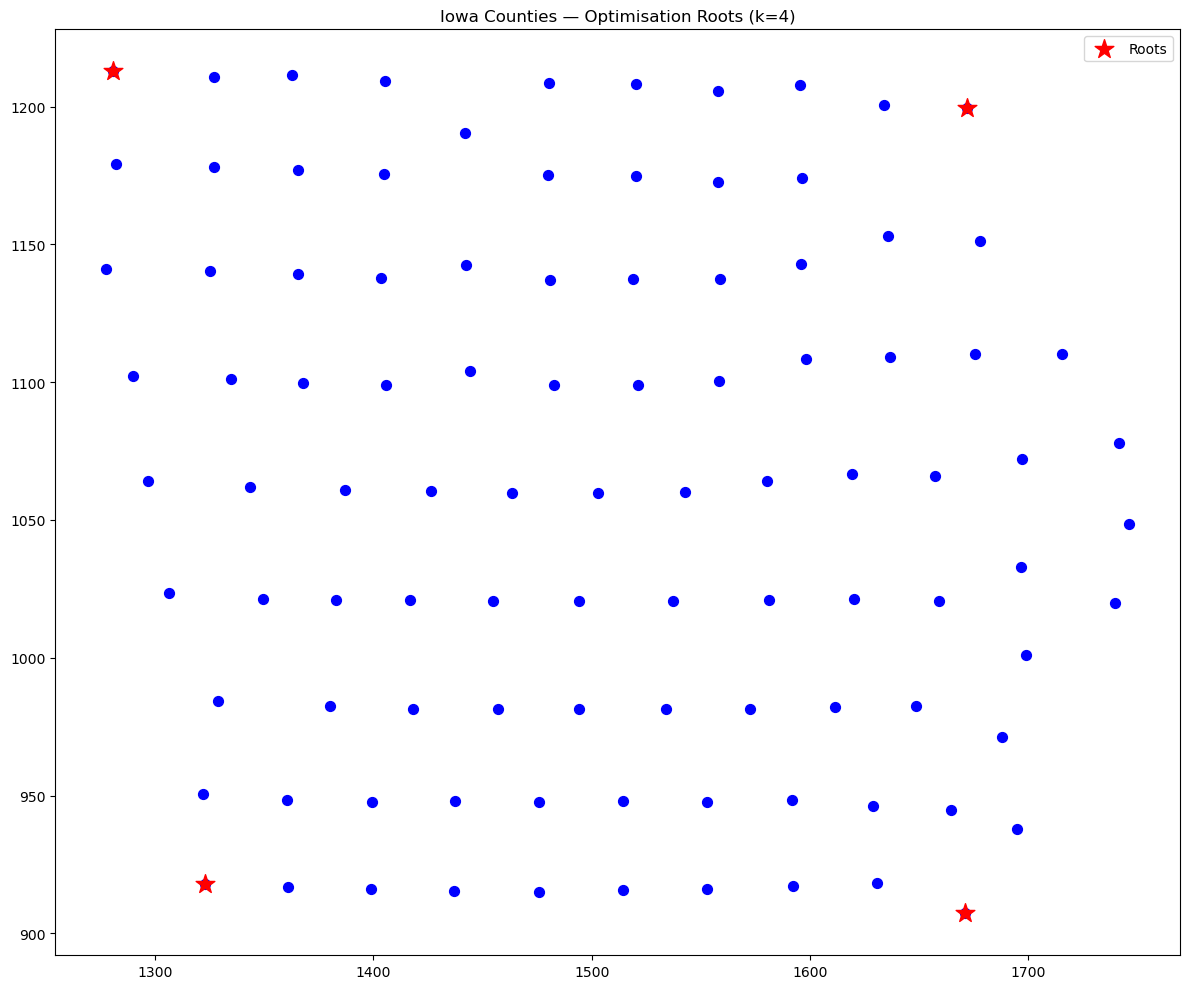

In [4]:
K = 4
roots = get_roots(G, k=K, root_strategy="corner")
print(f"Roots: {roots}")

fig = visualize_roots(G, roots, title="Iowa Counties — Optimisation Roots (k=4)")
plt.show()

In [13]:
DEVIATIONS = [50]
CONTIGUITY = ["tree", "dist", "dag", "cut"]
OBJECTIVES = [
    "hop_moi",
    "cut_edges", 
    "euclidean_moi",
]
TIME_LIMIT = 3600

total = len(DEVIATIONS) * len(CONTIGUITY) * len(OBJECTIVES)
print(f"Deviations : {DEVIATIONS}")
print(f"Contiguity : {CONTIGUITY}")
print(f"Objectives : {OBJECTIVES}")
print(f"Total experiments to runs : {total}")

Deviations : [50]
Contiguity : ['tree', 'dist', 'dag', 'cut']
Objectives : ['hop_moi', 'cut_edges', 'euclidean_moi']
Total experiments to runs : 12


In [ ]:
df = run_optimization_experiment(
    G_base=G,
    deviations=DEVIATIONS,
    contiguity_models=CONTIGUITY,
    objectives=OBJECTIVES,
    k=K,
    distance_metric= None, # Hop distance is used for contiguity by default, so no need to specify a distance metric
    time_limit=TIME_LIMIT,
    root_strategy="corner",
    results_file="../results/IA_county_all_50_hop_optimisation.csv",
)

Selected roots: [56, 26, 40, 27]
Distance metric: None

Total experiments: 12
Results will be saved to: ../results/IA_county_all_50_hop_optimisation.csv

[1/12] deviation=50 | contiguity=tree (dist: None) | objective_type=hop_moi
Using L, U, k = 797543 797642 4
Set parameter OutputFlag to value 1


Set parameter LogToConsole to value 1
Set parameter MIPGap to value 0
Set parameter PoolSearchMode to value 0
Set parameter PoolSolutions to value 1
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 22.6.0 22H730)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0
PoolSolutions  1

Optimize a model with 499 rows, 396 columns and 1972 nonzeros
Model fingerprint: 0x1a9d92c9
Variable types: 0 continuous, 396 integer (396 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+05]
  Objective range  [6e+03, 3e+07]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+05]
Presolve removed 316 rows and 249 columns
Presolve time: 0.01s
Presolved: 183 rows, 147 columns, 793 nonzeros
Variable types: 0 continuous, 147 integer (147 binary)

Root relaxation: objective 7.088991e+07, 35 iterations, 0.00 seconds (0.00 work units)

 

In [ ]:
df

,time_best,objective_type,objective,obj_bound,obj_gap,nonzeros,num_solutions,status,contiguity,sparsity,num_callbacks,num_lazy_cuts,roots,districts,deviation,contiguity_distance,k,distance_metric
0,0.897502,hop_moi,NaN,NaN,NaN,1972,0,Infeasible,tree,99.002044,0,0,"[56, 26, 40, 27]",None,50,None,4,None
1,1.797925,cut_edges,NaN,NaN,NaN,9520,0,Infeasible,tree,99.853747,0,0,"[56, 26, 40, 27]",None,50,None,4,None
2,40.846902,hop_moi,75821214.0,75821214.0,0.0,2228,1,Optimal,dist,98.872492,0,0,"[56, 26, 40, 27]","[[5, 7, 11, 15, 28, 34, 45, 51, 56, 61, 69, 72...",50,None,4,None
3,407.073731,cut_edges,51.0,51.0,0.0,9776,1,Optimal,dist,99.849815,0,0,"[56, 26, 40, 27]","[[5, 7, 11, 13, 15, 25, 29, 36, 45, 47, 50, 51...",50,None,4,None
4,40.704550,hop_moi,74826179.0,74826179.0,0.0,2468,1,Optimal,dag,98.751037,0,0,"[56, 26, 40, 27]","[[5, 6, 7, 11, 13, 15, 28, 29, 34, 51, 56, 69,...",50,None,4,None
5,3661.598158,cut_edges,NaN,NaN,NaN,10016,0,Time Limit,dag,99.846128,0,0,"[56, 26, 40, 27]",None,50,None,4,None
6,4225.069946,hop_moi,NaN,NaN,NaN,1188,0,Time Limit,cut,97.196262,15,214,"[56, 26, 40, 27]",None,50,N/A,4,None
7,4470.894386,cut_edges,NaN,NaN,NaN,8736,0,Time Limit,cut,99.843183,4,99,"[56, 26, 40, 27]",None,50,N/A,4,None
